In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("First 5 rows:")
print(df.head())


First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [ ]:
# Data Transformation
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print("\nNew Feature Created: FamilySize")
print(df[["SibSp","Parch","FamilySize"]].head())


New Feature Created: FamilySize
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


In [ ]:
# Feature Scaling
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

df["Age_filled"] = df["Age"].fillna(df["Age"].median())

df["Age_standard_scaled"] = scaler_standard.fit_transform(df[["Age_filled"]])
df["Age_minmax_scaled"] = scaler_minmax.fit_transform(df[["Age_filled"]])

print("\nScaled Age Values:")
print(df[["Age_filled","Age_standard_scaled","Age_minmax_scaled"]].head())


Scaled Age Values:
   Age_filled  Age_standard_scaled  Age_minmax_scaled
0        22.0            -0.565736           0.271174
1        38.0             0.663861           0.472229
2        26.0            -0.258337           0.321438
3        35.0             0.433312           0.434531
4        35.0             0.433312           0.434531


In [ ]:
# Binning
df["Age_Bin"] = pd.cut(df["Age_filled"],
                       bins=[0,12,20,40,60,80],
                       labels=["Child","Teen","Adult","Middle Age","Senior"])

print("\nAge Binning:")
print(df[["Age_filled","Age_Bin"]].head())


Age Binning:
   Age_filled Age_Bin
0        22.0   Adult
1        38.0   Adult
2        26.0   Adult
3        35.0   Adult
4        35.0   Adult



Skewness of Fare:
4.787316519674893


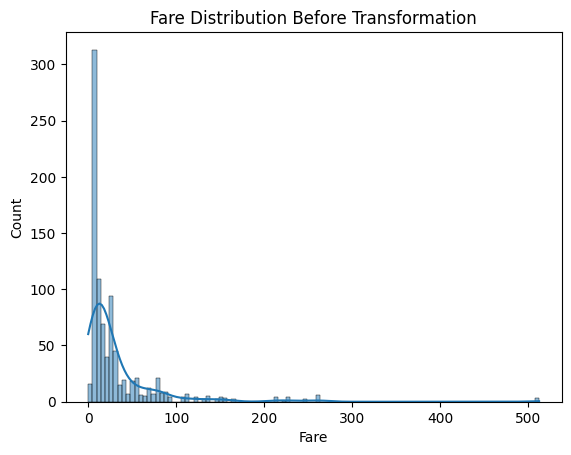

In [ ]:
# Detect Skewness
print("\nSkewness of Fare:")
print(df["Fare"].skew())

# Plot skewed distribution
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution Before Transformation")
plt.show()


Skewness after log transformation:
0.3949280095189306


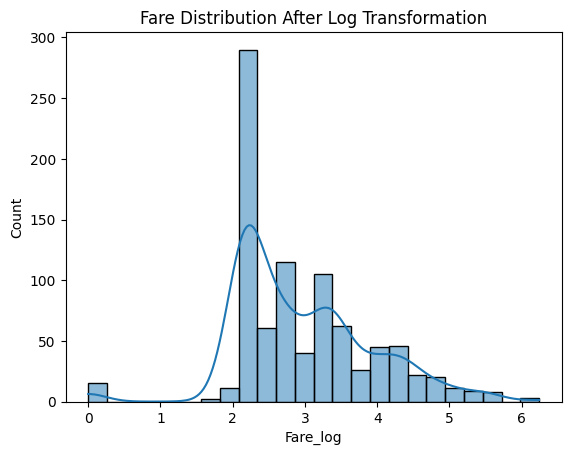

In [ ]:
# Fix Skewness
df["Fare_log"] = np.log1p(df["Fare"])

print("\nSkewness after log transformation:")
print(df["Fare_log"].skew())

sns.histplot(df["Fare_log"], kde=True)
plt.title("Fare Distribution After Log Transformation")
plt.show()

In [ ]:
# Sampling
sample_df = df.sample(frac=0.2, random_state=42)

print("\nSampled Dataset Shape:")
print(sample_df.shape)

print(sample_df.head())


Sampled Dataset Shape:
(178, 18)
     PassengerId  Survived  Pclass  \
709          710         1       3   
439          440         0       2   
840          841         0       3   
720          721         1       2   
39            40         1       3   

                                                  Name     Sex   Age  SibSp  \
709  Moubarek, Master. Halim Gonios ("William George")    male   NaN      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
840                        Alhomaki, Mr. Ilmari Rudolf    male  20.0      0   
720                  Harper, Miss. Annie Jessie "Nina"  female   6.0      0   
39                         Nicola-Yarred, Miss. Jamila  female  14.0      1   

     Parch            Ticket     Fare Cabin Embarked  FamilySize  Age_filled  \
709      1              2661  15.2458   NaN        C           3        28.0   
439      0        C.A. 18723  10.5000   NaN        S           1        31.0   
840      0  SOTON/O2 3